## 13. This question should be answered using the Weekly data set, which is part of the ISLP package. This data is similar in nature to the Smarket data from this chapter’s lab, except that it contains 1, 089 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

In [1]:
!pip install ISLP

In [2]:
from ISLP import load_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
from sklearn.metrics import confusion_matrix, accuracy_score

Weekly = load_data('Weekly')
sns.set_theme(style="whitegrid")

In [3]:
print(Weekly.describe())

Weekly.info()

numerical_vars = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today']

print(Weekly[numerical_vars].corr())

              Year         Lag1         Lag2         Lag3         Lag4  \
count  1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
mean   2000.048669     0.150585     0.151079     0.147205     0.145818   
std       6.033182     2.357013     2.357254     2.360502     2.360279   
min    1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%    1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%    2000.000000     0.241000     0.241000     0.241000     0.238000   
75%    2005.000000     1.405000     1.409000     1.409000     1.409000   
max    2010.000000    12.026000    12.026000    12.026000    12.026000   

              Lag5       Volume        Today  
count  1089.000000  1089.000000  1089.000000  
mean      0.139893     1.574618     0.149899  
std       2.361285     1.686636     2.356927  
min     -18.195000     0.087465   -18.195000  
25%      -1.166000     0.332022    -1.154000  
50%       0.234000     1.002680     0.241000  
75% 

## (a) Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

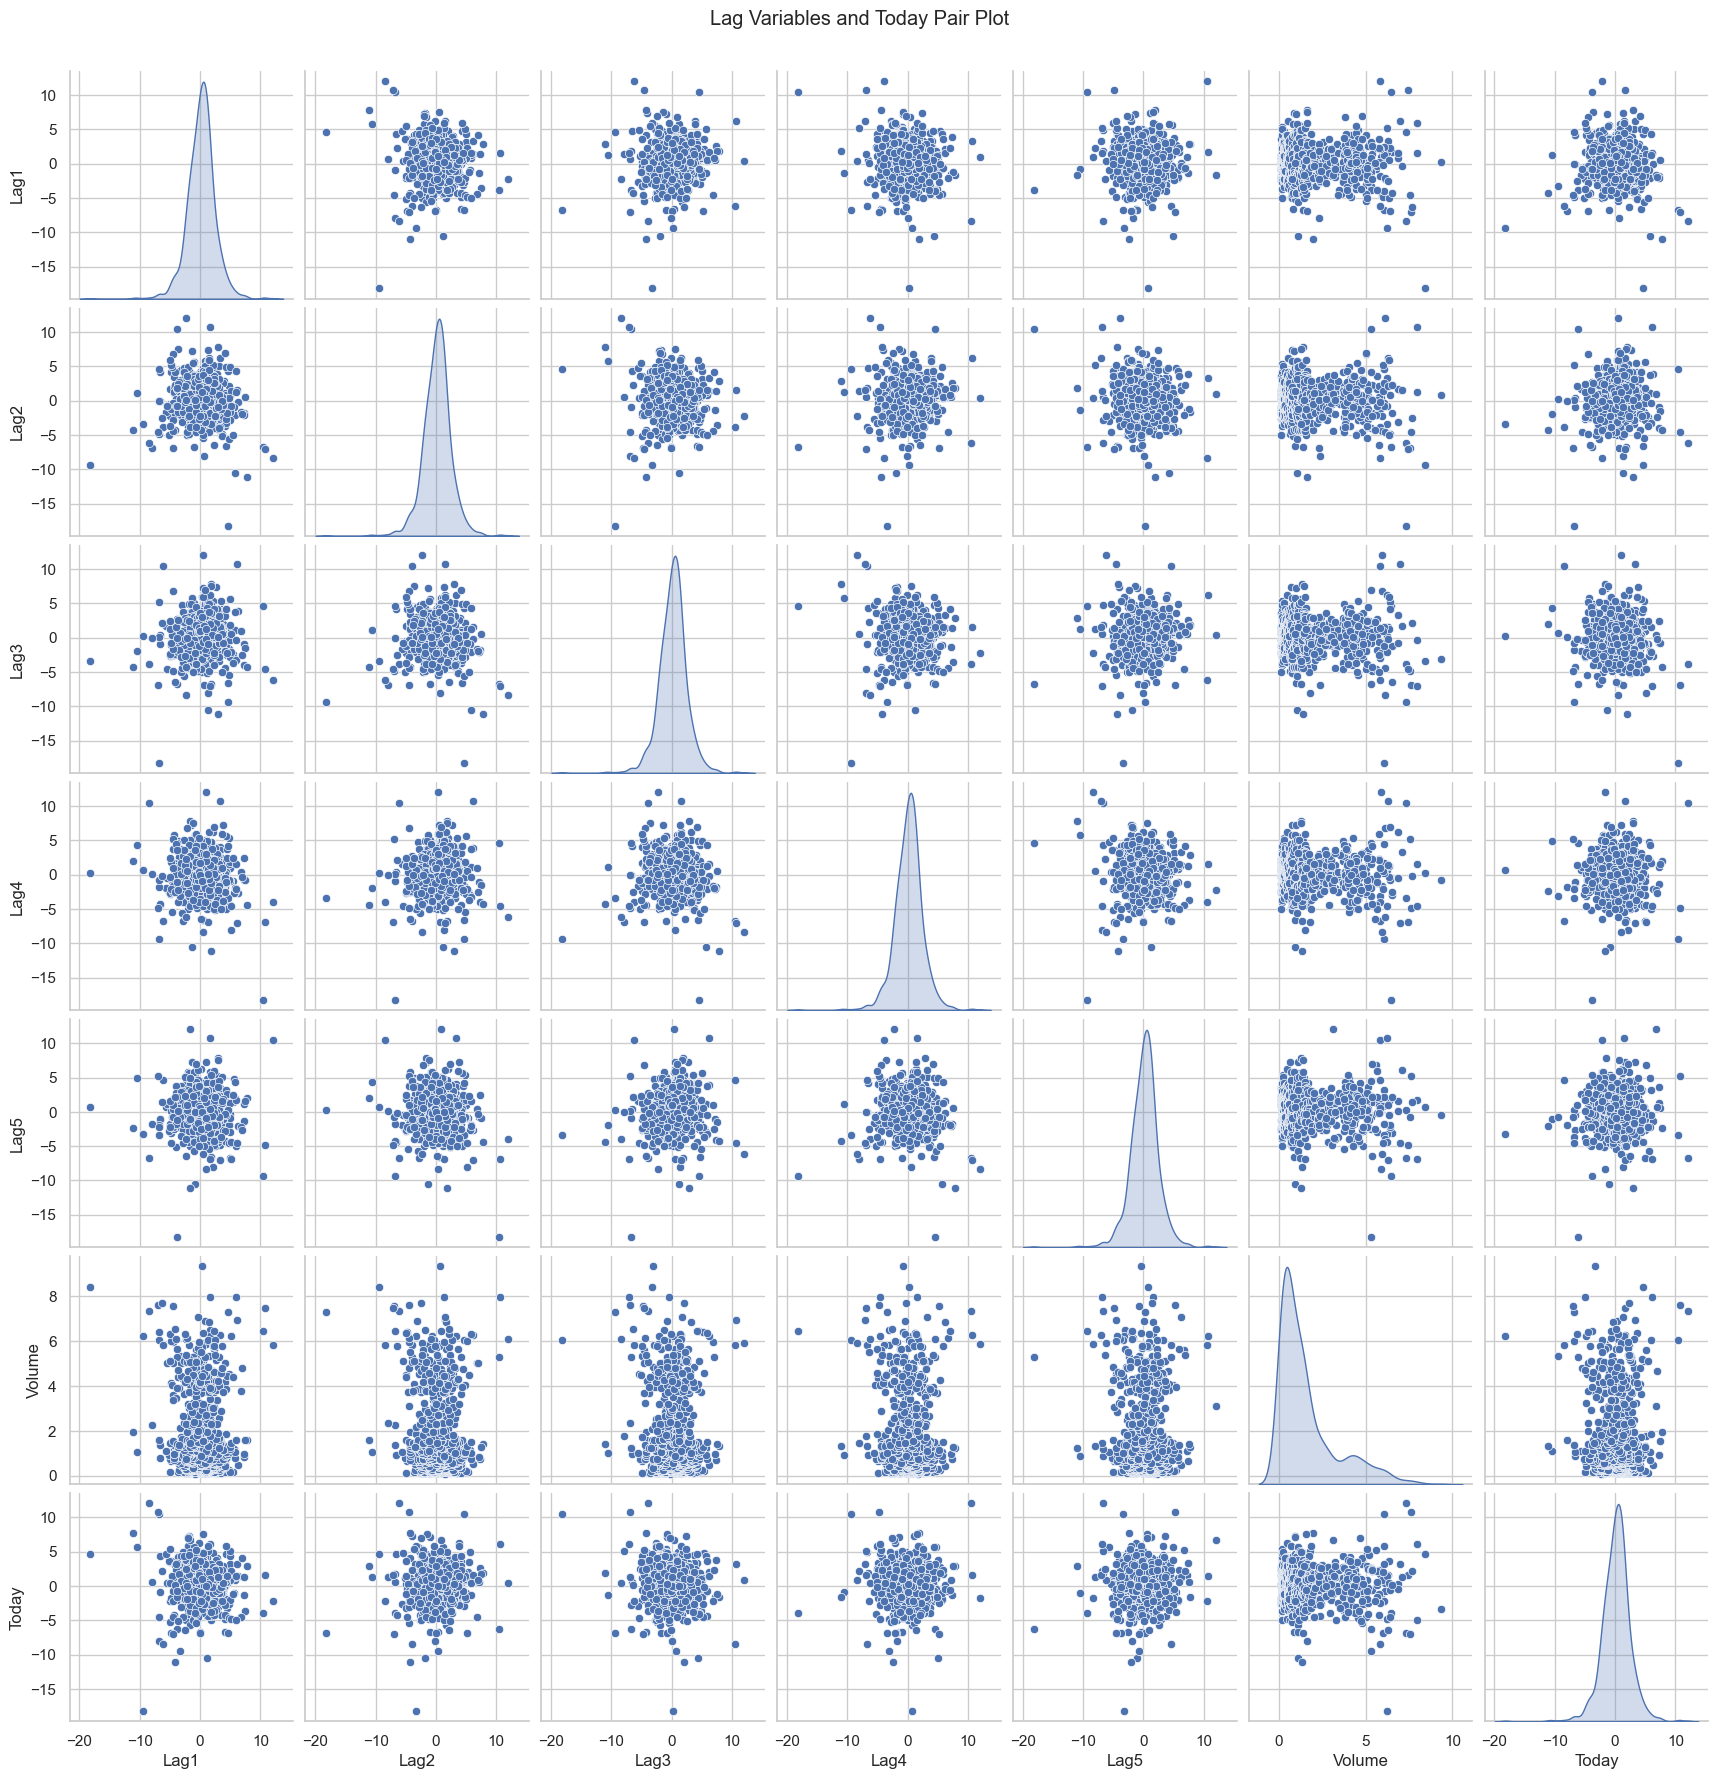

In [4]:
sns.pairplot(Weekly, vars=numerical_vars, diag_kind='kde')
plt.suptitle('Lag Variables and Today Pair Plot', y=1.02)
plt.show()

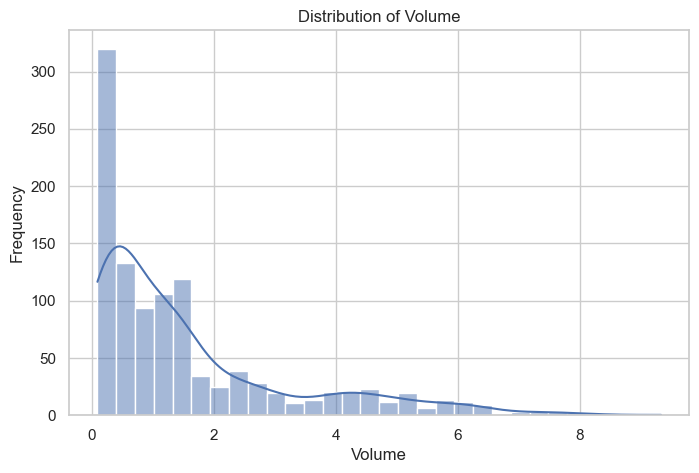

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(Weekly['Volume'], kde=True, bins=30)
plt.title('Distribution of Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()

### Conclusion
- There is no apparent linear relationship between the $\text{Lag}$ variables ($\text{Lag1}$ through $\text{Lag5}$). This suggests that past returns are mutually independent of each other.

- The linear trend between through $\text{Lag5}$ variables and through $\text{Volume}$) is not evident

### (b) Use the full data set to perform a logistic regression with Direction as the response and the fve lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically signifcant? If so, which ones?

In [6]:
Weekly['Direction_numeric'] = pd.factorize(Weekly['Direction'])[0]
Weekly['Direction_Up'] = (Weekly['Direction'] == 'Up').astype(int)

X = Weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y = Weekly['Direction_Up']
X = sm.add_constant(X)

glm_full = GLM(y, X, family=families.Binomial()).fit()

print(glm_full.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           Direction_Up   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Mon, 10 Nov 2025   Deviance:                       1486.4
Time:                        09:51:06   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.0


### Conclusion

**Based on the results, Lag2 is statistically significant because its P-value is less than $0.05$ ($0.030 < 0.05$).**

### (c) Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

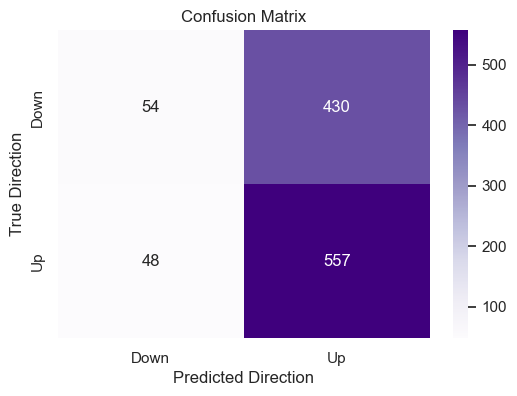


Accuracy: 0.5611 (56.11%)


In [7]:
probabilities = glm_full.predict(X)

predictions = (probabilities >= 0.5).astype(int)
conf_matrix = confusion_matrix(y, predictions)

accuracy = accuracy_score(y, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction')
plt.ylabel('True Direction')
plt.title('Confusion Matrix')
plt.show()

print(f"\nAccuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

### Result
| Metric | Value | Calculation | Interpretation | Note |
| :--- | :---: | :---: | :--- | :--- |
| **False Positive Rate (FPR)** | **88.84%** | 430 / 484 | The proportion of times the model incorrectly predicts **Up** when the market actually **went Down**. | This is the model's primary type of mistake. |
| **False Negative Rate (FNR)** | **7.93%** | 48 / 605 | The proportion of times the model incorrectly predicts **Down** when the market actually **went Up**. | This proportion is very low. |
| **True Negative Rate (TNR) / Specificity** | **11.16%** | 54 / 484 | The proportion of actual **Down** events that the model correctly predicted as Down. | This value is extremely low. |
| **True Positive Rate (TPR) / Sensitivity** | **92.07%** | 557 / 605 | The proportion of actual **Up** events that the model correctly predicted as Up. | This value is extremely high. |

### (d) Now ft the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

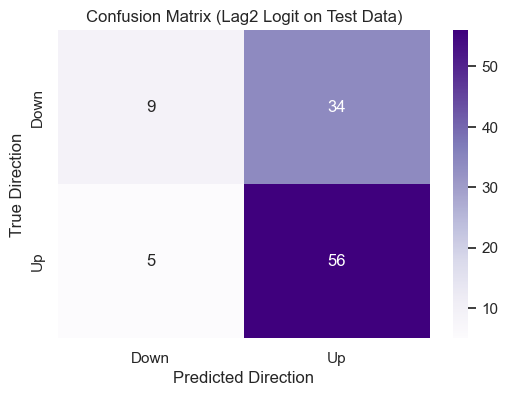


Accuracy: 0.6250 (62.50%)


In [9]:
# 劃分訓練集和測試集
train = Weekly['Year'] <= 2008
Weekly_train = Weekly[train].copy()
Weekly_test = Weekly[~train].copy()

X_train = Weekly_train[['Lag2']]
X_train = sm.add_constant(X_train)
y_train = Weekly_train['Direction_Up']
X_test = Weekly_test[['Lag2']]
X_test = sm.add_constant(X_test, prepend=True)
y_test = Weekly_test['Direction_Up']

# 訓練模型
glm_lag2 = GLM(y_train, X_train, family=families.Binomial()).fit()

probabilities_test = glm_lag2.predict(X_test)

predictions_test = (probabilities_test >= 0.5).astype(int)

conf_matrix_test = confusion_matrix(y_test, predictions_test)

accuracy_test = accuracy_score(y_test, predictions_test)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Purples', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction')
plt.ylabel('True Direction')
plt.title('Confusion Matrix (Lag2 Logit on Test Data)')
plt.show()

print(f"\nAccuracy: {accuracy_test:.4f} ({accuracy_test * 100:.2f}%)")

### (e) Repeat (d) using LDA.
### (f) Repeat (d) using QDA.
### (g) Repeat (d) using KNN with K = 1.
### (h) Repeat (d) using naive Bayes.


Accuracy (LDA): 0.6250
Accuracy (QDA): 0.5865
Accuracy (KNN, K=1): 0.5000
Accuracy (Naive Bayes): 0.5865


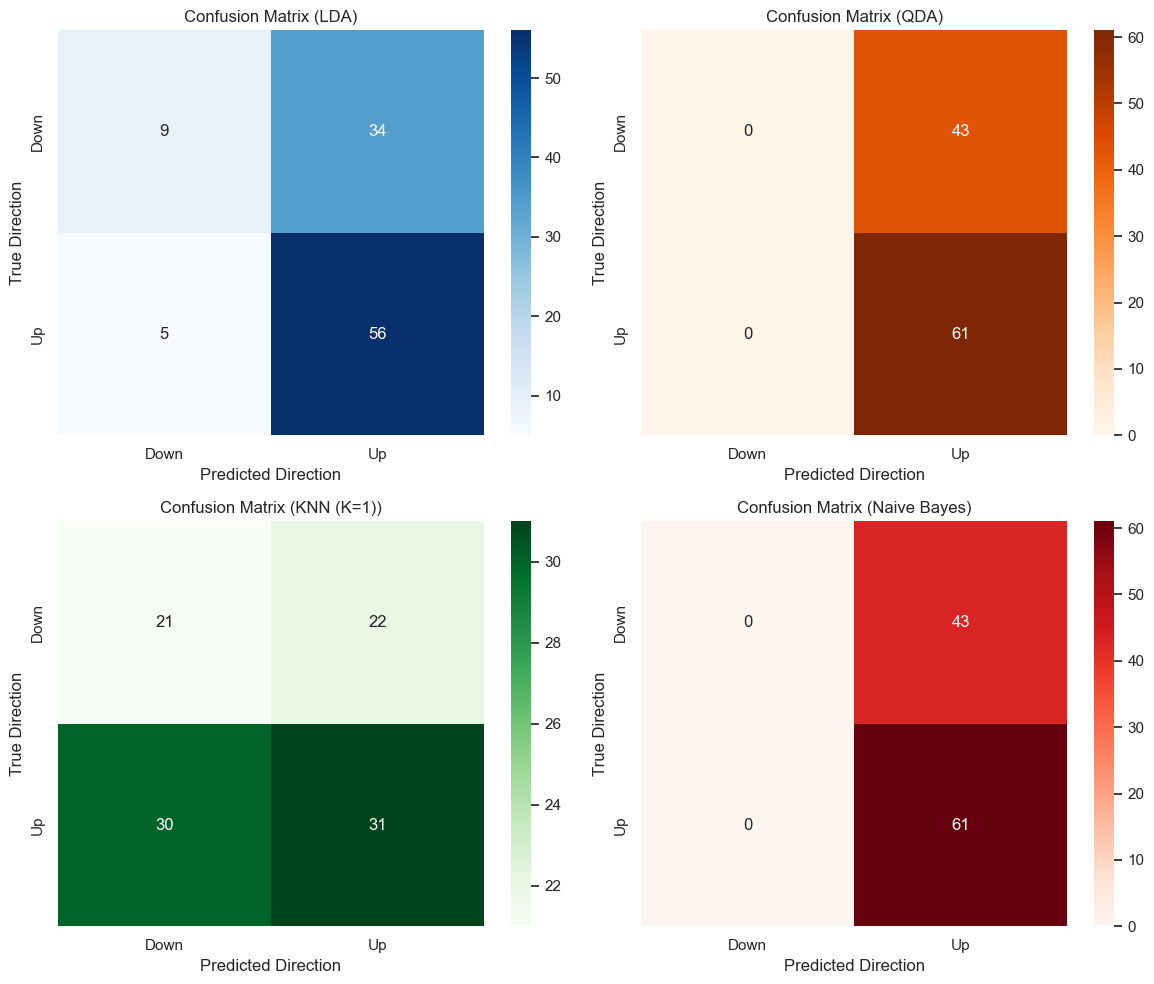


All Accuracy:
- LDA: 0.6250 (62.50%)
- Logit (Lag2): 0.6250 (62.50%)
- QDA: 0.5865 (58.65%)
- Naive Bayes: 0.5865 (58.65%)
- KNN (K=1): 0.5000 (50.00%)


In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

X_train_skl = Weekly_train[['Lag2']]
X_test_skl = Weekly_test[['Lag2']]
y_train_dir = Weekly_train['Direction']
y_test_dir = Weekly_test['Direction']

models = {}
accuracies = {}

# (e) LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_skl, y_train_dir)
predictions_lda = lda.predict(X_test_skl)
conf_matrix_lda = confusion_matrix(y_test_dir, predictions_lda)
accuracy_lda = accuracy_score(y_test_dir, predictions_lda)
accuracies['LDA'] = accuracy_lda
models['LDA'] = conf_matrix_lda
print(f"Accuracy (LDA): {accuracy_lda:.4f}")

# (f) QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_skl, y_train_dir)
predictions_qda = qda.predict(X_test_skl)
conf_matrix_qda = confusion_matrix(y_test_dir, predictions_qda)
accuracy_qda = accuracy_score(y_test_dir, predictions_qda)
accuracies['QDA'] = accuracy_qda
models['QDA'] = conf_matrix_qda
print(f"Accuracy (QDA): {accuracy_qda:.4f}")

# (g) KNN
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_skl, y_train_dir)
predictions_knn1 = knn1.predict(X_test_skl)
conf_matrix_knn1 = confusion_matrix(y_test_dir, predictions_knn1)
accuracy_knn1 = accuracy_score(y_test_dir, predictions_knn1)
accuracies['KNN (K=1)'] = accuracy_knn1
models['KNN (K=1)'] = conf_matrix_knn1
print(f"Accuracy (KNN, K=1): {accuracy_knn1:.4f}")

# (h) Naive Bayes
nb = GaussianNB()
nb.fit(X_train_skl, y_train_dir)
predictions_nb = nb.predict(X_test_skl)
conf_matrix_nb = confusion_matrix(y_test_dir, predictions_nb)
accuracy_nb = accuracy_score(y_test_dir, predictions_nb)
accuracies['Naive Bayes'] = accuracy_nb
models['Naive Bayes'] = conf_matrix_nb
print(f"Accuracy (Naive Bayes): {accuracy_nb:.4f}")

# 畫圖
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

plot_info = [
    ('LDA', models['LDA'], 'Blues'),
    ('QDA', models['QDA'], 'Oranges'),
    ('KNN (K=1)', models['KNN (K=1)'], 'Greens'),
    ('Naive Bayes', models['Naive Bayes'], 'Reds')
]

for i, (name, matrix, cmap) in enumerate(plot_info):
    sns.heatmap(matrix, annot=True, fmt='d', cmap=cmap, xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'],ax=axes[i])

    axes[i].set_title(f'Confusion Matrix ({name})')
    axes[i].set_xlabel('Predicted Direction')
    axes[i].set_ylabel('True Direction')

plt.tight_layout()
plt.show()

accuracies['Logit (Lag2)'] = accuracy_test

print("\nAll Accuracy:")
for name, acc in sorted(accuracies.items(), key=lambda item: item[1], reverse=True):
    print(f"- {name}: {acc:.4f} ({acc * 100:.2f}%)")


### (i)  Which of these methods appears to provide the best results on this data?

Logit and LDA method is best because of its hight accuracy.

| Model          | Predicted X | Accuracy      | Ranking |
|---------------------|-----------|------------------------|------|
| Logit (d)           | Lag2      | 0.6250 (62.50%)        | 1    |
| LDA (e)             | Lag2      | 0.6250 (62.50%)        | 1    |
| Naive Bayes (h)     | Lag2      | 0.5865 (58.65%)        | 3    |
| QDA (f)             | Lag2      | 0.5769 (57.69%)        | 4    |
| KNN (K=1) (g)       | Lag2      | 0.5000 (50.00%)        | 5    |



### (j) Experiment with diferent combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data. Note that you should also experiment with values for K in the KNN classifer.


### Change different N in KNN

In [11]:
best_knn_accuracy = 0
best_k = 0
best_knn_matrix = None

K_values = [1, 3, 5, 10]

print("Advanced KNN")
for k in K_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_skl, y_train_dir)
    predictions = knn.predict(X_test_skl)
    accuracy = accuracy_score(y_test_dir, predictions)

    print(f"KNN (K={k}) Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

    if accuracy > best_knn_accuracy:
        best_knn_accuracy = accuracy
        best_k = k
        best_knn_matrix = confusion_matrix(y_test_dir, predictions)

print(f"\n最佳 KNN 結果: K={best_k}, Accuracy={best_knn_accuracy:.4f} ({best_knn_accuracy * 100:.2f}%)")

Advanced KNN
KNN (K=1) Accuracy: 0.5000 (50.00%)
KNN (K=3) Accuracy: 0.5577 (55.77%)
KNN (K=5) Accuracy: 0.5288 (52.88%)
KNN (K=10) Accuracy: 0.5673 (56.73%)

最佳 KNN 結果: K=10, Accuracy=0.5673 (56.73%)


### Transformate the variables

In [12]:
# Lag2 的平方項
Weekly_train['Lag2_Squared'] = Weekly_train['Lag2'] ** 2
Weekly_test['Lag2_Squared'] = Weekly_test['Lag2'] ** 2

# 交互作用項: Lag1 x Lag2
Weekly_train['Lag1_Lag2_Interaction'] = Weekly_train['Lag1'] * Weekly_train['Lag2']
Weekly_test['Lag1_Lag2_Interaction'] = Weekly_test['Lag1'] * Weekly_test['Lag2']

# 對數變換: Log(Volume)
Weekly_train['Log_Volume'] = np.log(Weekly_train['Volume'])
Weekly_test['Log_Volume'] = np.log(Weekly_test['Volume'])

y_train_up = Weekly_train['Direction_Up']
y_test_up = Weekly_test['Direction_Up']

Logit (Lag1 + Log(Volume)) Accuracy: 0.5096


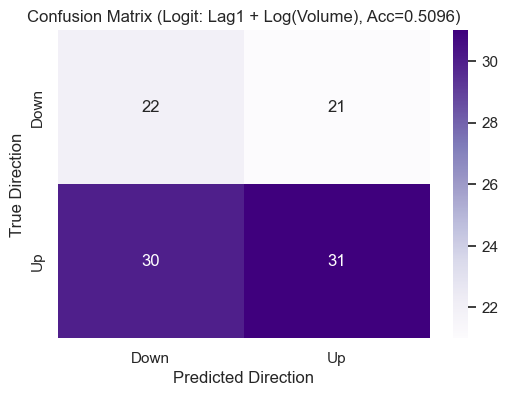

In [13]:
predictors_final = ['Lag1', 'Log_Volume']
X_train_final = Weekly_train[predictors_final]
X_test_final = Weekly_test[predictors_final]

X_train_final_const = sm.add_constant(X_train_final)
X_test_final_const = sm.add_constant(X_test_final, prepend=True)

glm_final = GLM(y_train_up, X_train_final_const, family=families.Binomial()).fit()
predictions_final = (glm_final.predict(X_test_final_const) >= 0.5).astype(int)

conf_matrix_final = confusion_matrix(y_test_up, predictions_final)
accuracy_final = accuracy_score(y_test_up, predictions_final)

print(f"Logit (Lag1 + Log(Volume)) Accuracy: {accuracy_final:.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_final,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=['Down', 'Up'],
            yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction')
plt.ylabel('True Direction')

plt.title(f'Confusion Matrix (Logit: Lag1 + Log(Volume), Acc={accuracy_final:.4f})')
plt.show()

Logit (Lag2 + Lag2^2) Accuracy: 0.6250


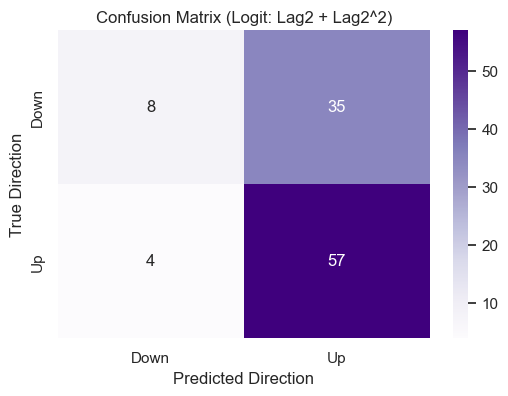

In [14]:
predictors_C = ['Lag2', 'Lag2_Squared']
X_train_C = Weekly_train[predictors_C]
X_test_C = Weekly_test[predictors_C]

X_train_C_const = sm.add_constant(X_train_C)
X_test_C_const = sm.add_constant(X_test_C, prepend=True)

glm_C = GLM(y_train_up, X_train_C_const, family=families.Binomial()).fit()
predictions_C = (glm_C.predict(X_test_C_const) >= 0.5).astype(int)

conf_matrix_C = confusion_matrix(y_test_up, predictions_C)
accuracy_C = accuracy_score(y_test_up, predictions_C)

print(f"Logit (Lag2 + Lag2^2) Accuracy: {accuracy_C:.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_C,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=['Down', 'Up'],
            yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction')
plt.ylabel('True Direction')
plt.title('Confusion Matrix (Logit: Lag2 + Lag2^2)')
plt.show()